# 2026-08-29 Paper II Q3: does RPS reshape surviving star formation?

This notebook implements the Q3 workflow. It is deliberately conditional on a region **surviving as star forming**:

$$P(\Delta\log\Sigma_{\rm SFR}\mid {\rm SF},\,{\rm RPS\ stage}).$$

The pre-peak population is the control. For every selected spaxel,

$$\Delta_i=\log\Sigma_{{\rm SFR},i}-\log\Sigma_{{\rm SFR,pre}}(\Sigma_{\star,i}),$$

and the pre-peak 16--84% control width at fixed $\Sigma_\star$ defines $z_{\rm SF}=\Delta/\sigma_{\rm pre}(\Sigma_\star)$.

## Scope and provenance

- Predecessor: `20260827_check_SF_fraction.ipynb`; the live catalogue, geometry, product discovery, WCS checks, mask semantics, combined `NGC4567_8` handling, and selection are reused.
- Usable-disc mask: `MASK==0`, finite stellar-mass and gas-bin maps, and valid geometry.
- Primary surviving-SF selection: finite `LOGSFR_SURFACE_DENSITY_HII`, EW(H$\alpha$)$>6$ Angstrom, and intrinsic H$\alpha$ dispersion $<45$ km s$^{-1}$.
- Galaxies, not spaxels, are the independent environmental units. Pooled distributions give each eligible galaxy equal total weight.
- The primary per-galaxy threshold is 50 supported SF spaxels; 20/50/100 are reported as sensitivity checks.
- Q4 spatial direction, metallicity, gas, pressure, and other physics branches are intentionally out of scope.
- Outputs stay embedded in this notebook; external saving is disabled by default.

## 1. Configuration

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"
GALAXY_COLOR_PATH = PROJECT_ROOT / "MAUVE_galaxy_colors.dat"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "paper2_Q3_surviving_SF_distribution"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DIAGNOSTIC_DIR = OUTPUT_DIR / "diagnostics"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU_PRIMARY = "LOGSFR_SURFACE_DENSITY_HII"
SFR_HDU_ROBUST = "LOGSFR_SURFACE_DENSITY_SF"
EW_HDU = "PROXY_EWHA"
EW_HA_MIN = 6.0
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
HALPHA_SIGMA_MAX = 45.0
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"               # live nGIST convention: 0 usable, 1 masked

N_SIGMA_BINS = 12
SIGMA_RANGE = (6.0, 10.0)          # fixed common grid; unsupported bins are masked later
R_EDGES = __import__('numpy').arange(0.0, 1.6 + 0.2, 0.2)
N_RADIUS_2D_BINS = len(R_EDGES) - 1

I_MAX_PRIMARY = 80.0
I_MAX_ROBUSTNESS = (60.0, 65.0, 70.0, 80.0)
N_BOOTSTRAP = 10_000
N_PERMUTATIONS = 10_000
MIN_SF_GAL_PRIMARY = 50
NMIN_SENSITIVITY = (20, 50, 100)
EQUAL_GALAXY_VIOLIN_DRAWS = 2_000
RANDOM_SEED = 42

MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
MIN_GALAXIES_PER_STAGE_BIN = 3
MIN_GALAXIES_PER_2D_CELL = 3
WCS_TOLERANCE_ARCSEC = 0.05
STRICT_VALIDATION = True
EXCLUDED_GALAXIES = {}             # mapping GALID -> explicit reason; empty by design
SAVE_OUTPUTS = False             # enable only when figure/CSV output is explicitly requested

STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
STAGE_COLORS = {
    "pre-peak": "#2166ac",
    "close-to-peak": "#1a9850",
    "post-peak": "#d73027",
}

if SAVE_OUTPUTS:
    for path in (FIGURE_DIR, TABLE_DIR, DIAGNOSTIC_DIR):
        path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Outputs: {OUTPUT_DIR} (disabled unless SAVE_OUTPUTS=True)")
print("No additional inclination correction will be applied to either surface-density map.")
print(f"SF selection: finite HII/SF map + {EW_HDU}>{EW_HA_MIN:g} Angstrom + intrinsic Halpha sigma<{HALPHA_SIGMA_MAX:g} km/s")


Project root: /Users/Igniz/Desktop/ICRAR/further
Data root: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Outputs: /Users/Igniz/Desktop/ICRAR/further/outputs/paper2_Q3_surviving_SF_distribution (disabled unless SAVE_OUTPUTS=True)
No additional inclination correction will be applied to either surface-density map.
SF selection: finite HII/SF map + PROXY_EWHA>6 Angstrom + intrinsic Halpha sigma<45 km/s


## 2. Imports and reusable helpers

In [2]:
from __future__ import annotations

import math
import warnings
from dataclasses import dataclass

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display
from scipy.special import expit

RNG = np.random.default_rng(RANDOM_SEED)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})


def save_table(frame: pd.DataFrame, filename: str) -> Path:
    path = TABLE_DIR / filename
    if SAVE_OUTPUTS:
        frame.to_csv(path, index=False)
    return path


def save_figure(fig, stem: str, *, diagnostic: bool = False):
    directory = DIAGNOSTIC_DIR if diagnostic else FIGURE_DIR
    if SAVE_OUTPUTS:
        fig.savefig(directory / f"{stem}.png", dpi=300, bbox_inches="tight")
        fig.savefig(directory / f"{stem}.pdf", bbox_inches="tight")


def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak",
        "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        names = {h.name.upper() for h in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data


def load_ngist_mask(path: Path, shape):
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)


def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa = WCS(header_a).celestial
    wb = WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)


def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247


def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    """Return min elliptical R/Re over physical components (union geometry for NGC4567_8)."""
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, row in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(ra, dec, row.center_ra_deg, row.center_dec_deg)
        pa = np.deg2rad(float(row.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        r = np.sqrt((major / float(row.a_re_arcsec)) ** 2 + (minor / float(row.b_re_arcsec)) ** 2)
        radius = np.minimum(radius, r)
    radius[~np.isfinite(radius)] = np.nan
    return radius


def make_valid_disc_mask(log_sigma_star, bin_id, ngist_mask, radius_re):
    return (
        np.isfinite(log_sigma_star)
        & np.isfinite(bin_id)
        & (ngist_mask == 0)
        & np.isfinite(radius_re)
    )


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = np.asarray(sigma_corr, dtype=float)
    if sigma_obs.shape != sigma_corr.shape:
        raise ValueError(
            f"Observed/correction Halpha sigma shape mismatch: {sigma_obs.shape} vs {sigma_corr.shape}"
        )
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[valid] = np.sqrt(sigma2_intrinsic[valid])
    return sigma_intrinsic


def make_sf_mask(valid_disc_mask, log_sigma_sfr, ew_ha, halpha_sigma_intrinsic):
    """Project SF definition: HII/SF map + EW(Halpha)>6 A + intrinsic sigma<45 km/s."""
    return (
        valid_disc_mask
        & np.isfinite(log_sigma_sfr)
        & np.isfinite(ew_ha)
        & (ew_ha > EW_HA_MIN)
        & np.isfinite(halpha_sigma_intrinsic)
        & (halpha_sigma_intrinsic < HALPHA_SIGMA_MAX)
    )


def load_galaxy_maps(row, geometry, sfr_hdu=SFR_HDU_PRIMARY):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, sfr_hdu)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    halpha_sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    halpha_sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    shapes = {
        mass.shape, mass_bin.shape, gas_bin.shape, sfr.shape, ew_ha.shape,
        halpha_sigma_obs.shape, halpha_sigma_corr.shape,
    }
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    if components.empty:
        raise KeyError(f"{row.GALID}: no geometry rows")
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    halpha_sigma_intrinsic = intrinsic_sigma_from_maps(halpha_sigma_obs, halpha_sigma_corr)
    valid = make_valid_disc_mask(mass, gas_bin, ngist_mask, radius_re)
    classification = valid & np.isfinite(sfr)
    sf = make_sf_mask(valid, sfr, ew_ha, halpha_sigma_intrinsic)
    return {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "ew_ha": ew_ha,
        "halpha_sigma_intrinsic": halpha_sigma_intrinsic,
        "mass_bin_id": mass_bin,
        "gas_bin_id": gas_bin,
        "ngist_mask": ngist_mask,
        "radius_re": radius_re,
        "valid_disc_mask": valid,
        "classification_mask": classification,
        "sf_mask": sf,
        "wcs_separation_arcsec": wcs_sep,
    }


def binned_indices(values, edges):
    return np.digitize(values, edges, right=False) - 1


def measure_fsf_by_sigma(row, maps, sigma_edges, *, aperture=np.inf):
    records = []
    x = maps["log_sigma_star"]
    y = maps["log_sigma_sfr"]
    r = maps["radius_re"]
    valid_base = maps["valid_disc_mask"] & (r < aperture)
    sf_base = maps["sf_mask"] & (r < aperture)
    for j, (lo, hi) in enumerate(zip(sigma_edges[:-1], sigma_edges[1:])):
        valid = valid_base & (x >= lo) & (x < hi)
        sf = sf_base & (x >= lo) & (x < hi)
        n_valid, n_sf = int(valid.sum()), int(sf.sum())
        records.append({
            "GALID": row.GALID, "stage": row.stage,
            "logMstar_global": row.logMstar_global, "inclination": row.inclination,
            "aperture": "full" if np.isinf(aperture) else "within_Re",
            "sigma_bin": j, "sigma_bin_lo": lo, "sigma_bin_hi": hi,
            "sigma_bin_center": (lo + hi) / 2,
            "N_valid": n_valid, "N_SF": n_sf,
            "f_SF": n_sf / n_valid if n_valid >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_median": np.nanmedian(y[sf]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_p16": np.nanpercentile(y[sf], 16) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_p84": np.nanpercentile(y[sf], 84) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_p90": np.nanpercentile(y[sf], 90) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_p95": np.nanpercentile(y[sf], 95) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(records)


def measure_by_radius(row, maps, radius_edges):
    records = []
    r, y = maps["radius_re"], maps["log_sigma_sfr"]
    for j, (lo, hi) in enumerate(zip(radius_edges[:-1], radius_edges[1:])):
        geometry_pixels = np.isfinite(r) & (r >= lo) & (r < hi)
        valid = maps["valid_disc_mask"] & (r >= lo) & (r < hi)
        sf = maps["sf_mask"] & (r >= lo) & (r < hi)
        n_geometry, n_valid, n_sf = map(int, (geometry_pixels.sum(), valid.sum(), sf.sum()))
        records.append({
            "GALID": row.GALID, "stage": row.stage,
            "radius_bin": j, "radius_lo": lo, "radius_hi": hi, "radius_center": (lo + hi) / 2,
            "N_geometry": n_geometry, "N_valid": n_valid, "N_SF": n_sf,
            "f_coverage": n_valid / n_geometry if n_geometry else np.nan,
            "f_SF": n_sf / n_valid if n_valid >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "surv_logSigmaSFR_median": np.nanmedian(y[sf]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(records)


def measure_fsf_2d(row, maps, sigma_edges, radius_edges):
    records = []
    x, r = maps["log_sigma_star"], maps["radius_re"]
    for i, (slo, shi) in enumerate(zip(sigma_edges[:-1], sigma_edges[1:])):
        for j, (rlo, rhi) in enumerate(zip(radius_edges[:-1], radius_edges[1:])):
            cell = (x >= slo) & (x < shi) & (r >= rlo) & (r < rhi)
            valid, sf = maps["valid_disc_mask"] & cell, maps["sf_mask"] & cell
            nv, ns = int(valid.sum()), int(sf.sum())
            records.append({
                "GALID": row.GALID, "stage": row.stage, "sigma_bin": i, "radius_bin": j,
                "sigma_center": (slo + shi) / 2, "radius_center": (rlo + rhi) / 2,
                "N_valid": nv, "N_SF": ns,
                "f_SF": ns / nv if nv >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            })
    return pd.DataFrame(records)


def bootstrap_median(values, *, n_boot=N_BOOTSTRAP, rng=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.full(n_boot, np.nan)
    rng = RNG if rng is None else rng
    draws = rng.choice(values, size=(n_boot, values.size), replace=True)
    return np.nanmedian(draws, axis=1)


def stage_summary(frame, value_col, bin_col, *, min_galaxies=MIN_GALAXIES_PER_STAGE_BIN):
    rows = []
    for bin_value, bin_frame in frame.groupby(bin_col, sort=True):
        for stage in STAGE_ORDER:
            values = bin_frame.loc[bin_frame.stage.eq(stage), value_col].dropna().to_numpy()
            rec = {bin_col: bin_value, "stage": stage, "Ngal": len(values)}
            if len(values) >= min_galaxies:
                boot = bootstrap_median(values)
                rec.update({
                    "median": np.median(values), "scatter_p16": np.percentile(values, 16),
                    "scatter_p84": np.percentile(values, 84),
                    "boot_p2p5": np.percentile(boot, 2.5), "boot_p16": np.percentile(boot, 16),
                    "boot_p84": np.percentile(boot, 84), "boot_p97p5": np.percentile(boot, 97.5),
                })
            else:
                rec.update({k: np.nan for k in ["median", "scatter_p16", "scatter_p84", "boot_p2p5", "boot_p16", "boot_p84", "boot_p97p5"]})
            rows.append(rec)
    return pd.DataFrame(rows)


def add_prepeak_reference(frame):
    result = frame.copy()
    ref = (result.loc[result.stage.eq("pre-peak")]
           .groupby("sigma_bin")["surv_logSigmaSFR_median"].median()
           .rename("prepeak_reference"))
    result = result.merge(ref, on="sigma_bin", how="left", validate="many_to_one")
    result["surv_deltaSFR"] = result["surv_logSigmaSFR_median"] - result["prepeak_reference"]
    return result


def bootstrap_stage_difference(frame, value_col, bin_col, stage_a, stage_b):
    rows = []
    for bin_value, group in frame.groupby(bin_col, sort=True):
        a = group.loc[group.stage.eq(stage_a), value_col].dropna().to_numpy()
        b = group.loc[group.stage.eq(stage_b), value_col].dropna().to_numpy()
        rec = {bin_col: bin_value, "metric": value_col, "comparison": f"{stage_a}_minus_{stage_b}",
               "Ngal_a": len(a), "Ngal_b": len(b)}
        if min(len(a), len(b)) >= MIN_GALAXIES_PER_STAGE_BIN:
            rng = np.random.default_rng(RANDOM_SEED + int(bin_value) * 101 + len(rows))
            diff = bootstrap_median(a, rng=rng) - bootstrap_median(b, rng=rng)
            rec.update({
                "median_difference": np.median(diff), "p2p5": np.percentile(diff, 2.5),
                "p16": np.percentile(diff, 16), "p84": np.percentile(diff, 84),
                "p97p5": np.percentile(diff, 97.5),
                "fraction_above_zero": np.mean(diff > 0), "fraction_below_zero": np.mean(diff < 0),
            })
        else:
            rec.update({k: np.nan for k in ["median_difference", "p2p5", "p16", "p84", "p97p5", "fraction_above_zero", "fraction_below_zero"]})
        rows.append(rec)
    return pd.DataFrame(rows)


def plot_stage_summary(ax, summary, x_lookup, *, ylabel, title, zero=False):
    for stage in STAGE_ORDER:
        s = summary.loc[summary.stage.eq(stage)].sort_values(summary.columns[0])
        x = s[summary.columns[0]].map(x_lookup)
        supported = s.Ngal.ge(MIN_GALAXIES_PER_STAGE_BIN) & s["median"].notna()
        ax.plot(x[supported], s.loc[supported, "median"], marker="o", lw=2.4,
                color=STAGE_COLORS[stage], label=stage)
        ax.fill_between(x[supported], s.loc[supported, "scatter_p16"], s.loc[supported, "scatter_p84"],
                        color=STAGE_COLORS[stage], alpha=0.16, linewidth=0,
                        label="galaxy 16--84% scatter" if stage == STAGE_ORDER[0] else None)
    if zero:
        ax.axhline(0, color="0.3", ls="--", lw=1)
    ax.set(ylabel=ylabel, title=title)
    ax.grid(alpha=0.25)



def load_galaxy_colors(path):
    """Read the fixed, project-approved MAUVE galaxy colour mapping."""
    colors = {}
    for line in path.read_text().splitlines():
        fields = line.split()
        if not fields or fields[0].startswith("#") or fields[0] == "reserved":
            continue
        if fields[0] == "alias":
            colors[fields[1]] = fields[3]
        elif fields[0].isdigit():
            colors[fields[1]] = fields[3]
    return colors


def weighted_quantile(values, quantiles, weights=None):
    """Linear weighted quantiles; finite values with strictly positive weights only."""
    values = np.asarray(values, dtype=float)
    quantiles = np.atleast_1d(np.asarray(quantiles, dtype=float))
    if weights is None:
        weights = np.ones(values.size, dtype=float)
    weights = np.asarray(weights, dtype=float)
    keep = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values, weights = values[keep], weights[keep]
    if values.size == 0:
        return np.full(quantiles.shape, np.nan)
    order = np.argsort(values)
    values, weights = values[order], weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative /= weights.sum()
    return np.interp(quantiles, cumulative, values, left=values[0], right=values[-1])


def interpolate_supported_reference(x, reference):
    supported = reference.loc[reference.supported & reference.reference.notna()].sort_values("sigma_center")
    if len(supported) < 2:
        return np.full(np.asarray(x).shape, np.nan)
    return np.interp(
        np.asarray(x, dtype=float),
        supported.sigma_center.to_numpy(),
        supported.reference.to_numpy(),
        left=np.nan,
        right=np.nan,
    )


def equal_galaxy_stage_payload(distributions, metrics, stage, value_key="delta"):
    """Concatenate eligible galaxies with unit total weight per galaxy."""
    eligible = metrics.loc[metrics.stage.eq(stage) & metrics.eligible_primary, "GALID"]
    values, weights = [], []
    for galid in eligible:
        arr = np.asarray(distributions[galid][value_key], dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size:
            values.append(arr)
            weights.append(np.full(arr.size, 1.0 / (len(eligible) * arr.size)))
    if not values:
        return np.array([]), np.array([])
    return np.concatenate(values), np.concatenate(weights)


def weighted_ecdf(values, weights):
    order = np.argsort(values)
    x, w = np.asarray(values)[order], np.asarray(weights)[order]
    return x, np.cumsum(w) / np.sum(w)


def galaxy_metric_row(galid, stage, delta, z):
    delta = np.asarray(delta, dtype=float)
    z = np.asarray(z, dtype=float)
    delta = delta[np.isfinite(delta)]
    z = z[np.isfinite(z)]
    q16, q50, q84 = np.nanpercentile(delta, [16, 50, 84]) if delta.size else (np.nan,) * 3
    f_enh = np.mean(z > 1) if z.size else np.nan
    f_sup = np.mean(z < -1) if z.size else np.nan
    f_strong_enh = np.mean(z > 2) if z.size else np.nan
    f_strong_sup = np.mean(z < -2) if z.size else np.nan
    width = (q84 - q16) / 2 if delta.size else np.nan
    asymmetry = ((q84 - q50) - (q50 - q16)) / (q84 - q16) if delta.size and q84 > q16 else np.nan
    return {
        "GALID": galid, "stage": stage, "N_delta": delta.size, "N_z": z.size,
        "P16": q16, "M": q50, "P84": q84, "W": width,
        "f_enh": f_enh, "f_sup": f_sup,
        "f_strong_enh": f_strong_enh, "f_strong_sup": f_strong_sup,
        "F_tail": f_enh + f_sup, "A_tail": f_enh - f_sup, "S_asym": asymmetry,
    }


def bootstrap_stage_metrics(metrics, metric_names, n_boot=N_BOOTSTRAP):
    rows = []
    for metric in metric_names:
        for stage_index, stage in enumerate(STAGE_ORDER):
            values = metrics.loc[metrics.stage.eq(stage) & metrics.eligible_primary, metric].dropna().to_numpy()
            rec = {"metric": metric, "stage": stage, "Ngal": len(values)}
            if values.size:
                rng = np.random.default_rng(RANDOM_SEED + 1000 * stage_index + 37 * metric_names.index(metric))
                draws = rng.choice(values, size=(n_boot, values.size), replace=True)
                medians = np.median(draws, axis=1)
                rec.update({
                    "median": np.median(values),
                    "galaxy_p16": np.percentile(values, 16),
                    "galaxy_p84": np.percentile(values, 84),
                    "boot_p2p5": np.percentile(medians, 2.5),
                    "boot_p16": np.percentile(medians, 16),
                    "boot_p84": np.percentile(medians, 84),
                    "boot_p97p5": np.percentile(medians, 97.5),
                })
            rows.append(rec)
    return pd.DataFrame(rows)


def permutation_stage_differences(metrics, metric_names, n_perm=N_PERMUTATIONS):
    rows = []
    for metric_index, metric in enumerate(metric_names):
        for comparison_index, (stage_a, stage_b) in enumerate((
            ("close-to-peak", "pre-peak"), ("post-peak", "pre-peak")
        )):
            a = metrics.loc[metrics.stage.eq(stage_a) & metrics.eligible_primary, metric].dropna().to_numpy()
            b = metrics.loc[metrics.stage.eq(stage_b) & metrics.eligible_primary, metric].dropna().to_numpy()
            observed = np.median(a) - np.median(b)
            pooled = np.concatenate([a, b])
            rng = np.random.default_rng(RANDOM_SEED + 100 * metric_index + comparison_index)
            random_differences = np.empty(n_perm, dtype=float)
            for k in range(n_perm):
                shuffled = rng.permutation(pooled)
                random_differences[k] = np.median(shuffled[:len(a)]) - np.median(shuffled[len(a):])
            rows.append({
                "metric": metric, "comparison": f"{stage_a}_minus_{stage_b}",
                "Ngal_a": len(a), "Ngal_b": len(b), "observed_difference": observed,
                "p_permutation_two_sided": (np.count_nonzero(np.abs(random_differences) >= abs(observed)) + 1) / (n_perm + 1),
            })
    return pd.DataFrame(rows)


def draw_stage_points_and_summary(ax, metrics, summary, metric, ylabel, *, zero=False):
    galaxy_colors = load_galaxy_colors(GALAXY_COLOR_PATH)
    rng = np.random.default_rng(RANDOM_SEED + sum(map(ord, metric)))
    for x0, stage in enumerate(STAGE_ORDER):
        subset = metrics.loc[metrics.stage.eq(stage) & metrics.eligible_primary].sort_values("GALID")
        jitter = rng.uniform(-0.15, 0.15, len(subset))
        ax.scatter(
            x0 + jitter, subset[metric], s=47,
            c=[galaxy_colors.get(g, "0.45") for g in subset.GALID],
            edgecolors=STAGE_COLORS[stage], linewidths=1.35, alpha=0.95, zorder=3,
        )
        stat = summary.loc[summary.metric.eq(metric) & summary.stage.eq(stage)].iloc[0]
        ax.vlines(x0, stat.boot_p16, stat.boot_p84, color="black", lw=4.0, zorder=4)
        ax.scatter(x0, stat["median"], marker="D", s=70, c="black", zorder=5)
    if zero:
        ax.axhline(0, color="0.35", ls="--", lw=1)
    ax.set_xticks(range(len(STAGE_ORDER)), ["pre", "close", "post"])
    ax.set(ylabel=ylabel)
    ax.grid(axis="y", alpha=0.25)


## 3. Live catalogue, product inventory, and stage consistency

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        required = {"Galaxy", "logMstar", "class"}
        missing = required - set(table.names)
        if missing:
            raise KeyError(f"{path}: missing catalogue columns {sorted(missing)}")
        frame = pd.DataFrame({
            "galaxy": [str(v).strip() for v in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(p for p in data_root.iterdir() if p.is_dir() and not p.name.endswith("_logs")):
        galid = folder.name
        mass = folder / MASS_FILE_PATTERN.format(galid=galid)
        sfr = first_existing([folder / p.format(galid=galid) for p in SFR_FILE_PATTERNS])
        ew = first_existing([folder / p.format(galid=galid) for p in EW_FILE_PATTERNS])
        mask = folder / MASK_FILE_PATTERN.format(galid=galid)
        rows.append({"GALID": galid, "mass_path": mass, "sfr_path": sfr, "ew_path": ew, "mask_path": mask})
    return pd.DataFrame(rows)


master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg", "center_dec_deg",
    "inclination_deg", "pa_deg_east_of_north", "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")
if geometry.galaxy.duplicated().any():
    raise ValueError("Geometry catalogue contains duplicate physical-galaxy rows")

geometry = geometry.merge(master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left", validate="one_to_one")
if geometry[["logMstar", "stage"]].isna().any().any():
    raise RuntimeError("Geometry/master catalogue merge left missing mass or stage values")
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    bad = geometry.loc[~geometry.stage.eq(geometry.stage_from_geometry), ["galaxy", "stage", "stage_from_geometry"]]
    raise RuntimeError(f"Stage disagreement between catalogues:\n{bad}")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "logMstar_global": np.log10(np.sum(10 ** group.logMstar.to_numpy())),
        "inclination": group.inclination_deg.max(),
    })
product_meta = pd.DataFrame(product_meta)

inventory = product_meta.merge(discover_products(DATA_ROOT), on="GALID", how="outer", validate="one_to_one")
inventory["manual_exclusion_reason"] = inventory.GALID.map(EXCLUDED_GALAXIES).fillna("")
inventory["analysis_candidate"] = inventory.manual_exclusion_reason.eq("")

def path_exists(value):
    return isinstance(value, Path) and value.exists()

inventory["mass_exists"] = inventory.mass_path.map(path_exists)
inventory["sfr_exists"] = inventory.sfr_path.map(path_exists)
inventory["ew_exists"] = inventory.ew_path.map(path_exists)
inventory["mask_exists"] = inventory.mask_path.map(path_exists)
inventory["catalogue_complete"] = inventory[["stage", "logMstar_global", "inclination"]].notna().all(axis=1)
display(inventory[["GALID", "components", "stage", "logMstar_global", "inclination",
                   "mass_exists", "sfr_exists", "ew_exists", "mask_exists", "manual_exclusion_reason"]])
print("Inventory stage counts:", inventory.groupby("stage").GALID.nunique().to_dict())


,GALID,components,stage,logMstar_global,inclination,mass_exists,sfr_exists,ew_exists,mask_exists,manual_exclusion_reason
0,IC3392,IC3392,post-peak,9.823572,68,True,True,True,True,
1,NGC4064,NGC4064,post-peak,10.046130,70,True,True,True,True,
2,NGC4189,NGC4189,pre-peak,9.734349,42,True,True,True,True,
3,NGC4192,NGC4192,pre-peak,10.764349,83,True,True,True,True,
4,NGC4216,NGC4216,post-peak,10.894349,90,False,False,False,False,
5,NGC4222,NGC4222,pre-peak,9.434349,90,True,True,True,True,
6,NGC4254,NGC4254,pre-peak,10.504350,39,True,True,True,True,
7,NGC4293,NGC4293,post-peak,10.526728,67,True,True,True,True,
8,NGC4294,NGC4294,pre-peak,9.364349,74,True,True,True,True,
9,NGC4298,NGC4298,close-to-peak,10.094349,52,True,True,True,True,


Inventory stage counts: {'close-to-peak': 10, 'post-peak': 18, 'pre-peak': 11}


## 4. Product validation and primary-sample QC

In [4]:
qc_rows = []
for row in inventory.itertuples(index=False):
    flags = []
    maps = None
    if not row.analysis_candidate:
        flags.append(f"manual_exclusion:{row.manual_exclusion_reason}")
    for label, exists in (("mass", row.mass_exists), ("sfr", row.sfr_exists), ("ew", row.ew_exists), ("mask", row.mask_exists)):
        if not exists:
            flags.append(f"missing_{label}_product")
    if not row.catalogue_complete:
        flags.append("missing_catalogue_metadata")
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry, SFR_HDU_PRIMARY)
            valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
            classified = maps["classification_mask"]
            if np.any(sf & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    valid = maps["valid_disc_mask"] if maps is not None else np.zeros(0, dtype=bool)
    sf = maps["sf_mask"] if maps is not None else np.zeros(0, dtype=bool)
    classified = maps["classification_mask"] if maps is not None else np.zeros(0, dtype=bool)
    qc_rows.append({
        "GALID": row.GALID, "components": row.components, "stage": row.stage,
        "logMstar_global": row.logMstar_global, "inclination": row.inclination,
        "N_valid_stellar_pixels": int(valid.sum()),
        "N_HII_classified_pixels_before_EW_sigma": int(classified.sum()),
        "N_HII_EW_sigma_SF_pixels": int(sf.sum()),
        "selected_SF_area_fraction": float(sf.sum() / valid.sum()) if valid.size and valid.sum() else np.nan,
        "max_usable_R_over_Re": float(np.nanmax(maps["radius_re"][valid])) if maps is not None and valid.any() else np.nan,
        "logSigmaStar_min": float(np.nanmin(maps["log_sigma_star"][valid])) if maps is not None and valid.any() else np.nan,
        "logSigmaStar_max": float(np.nanmax(maps["log_sigma_star"][valid])) if maps is not None and valid.any() else np.nan,
        "logSigmaSFR_min": float(np.nanmin(maps["log_sigma_sfr"][sf])) if maps is not None and sf.any() else np.nan,
        "logSigmaSFR_max": float(np.nanmax(maps["log_sigma_sfr"][sf])) if maps is not None and sf.any() else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"] if maps is not None else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })

qc = pd.DataFrame(qc_rows)
save_table(qc, "Q3_sample_QC.csv")
display(qc)
failures = qc.loc[qc.QC_flag.str.contains("load_error|sf_not_subset_of_valid|missing_catalogue_metadata", regex=True)]
if STRICT_VALIDATION and not failures.empty:
    raise RuntimeError("Strict validation failed. Inspect outputs/paper2_Q3_first_order_SF/tables/Q3_sample_QC.csv")

primary = inventory.loc[
    inventory.analysis_candidate & inventory.GALID.isin(qc.loc[qc.QC_flag.eq("OK"), "GALID"])
    & inventory.inclination.lt(I_MAX_PRIMARY)
].copy()
print(f"Primary i < {I_MAX_PRIMARY:.0f} deg sample: {len(primary)} products")
print(primary.groupby("stage").GALID.nunique().reindex(STAGE_ORDER, fill_value=0).to_dict())
if (primary.groupby("stage").GALID.nunique().reindex(STAGE_ORDER, fill_value=0) < MIN_GALAXIES_PER_STAGE_BIN).any():
    raise RuntimeError("Primary sample lacks the minimum galaxy count in at least one stage")


,GALID,components,stage,logMstar_global,inclination,N_valid_stellar_pixels,N_HII_classified_pixels_before_EW_sigma,N_HII_EW_sigma_SF_pixels,selected_SF_area_fraction,max_usable_R_over_Re,logSigmaStar_min,logSigmaStar_max,logSigmaSFR_min,logSigmaSFR_max,wcs_separation_arcsec,QC_flag
0,IC3392,IC3392,post-peak,9.823572,68,94575,14845,13897,0.146942,3.084733,6.969276,9.253759,-2.814456,-0.912330,0.0,OK
1,NGC4064,NGC4064,post-peak,10.046130,70,179882,7820,3273,0.018195,1.939061,6.811374,9.428892,-2.878540,-0.062300,0.0,OK
2,NGC4189,NGC4189,pre-peak,9.734349,42,177204,100340,96364,0.543803,2.270596,6.873473,9.774550,-3.243131,0.244948,0.0,OK
3,NGC4192,NGC4192,pre-peak,10.764349,83,524447,153872,144333,0.275210,2.209738,6.785489,10.584879,-3.711207,-0.247443,0.0,OK
4,NGC4216,NGC4216,post-peak,10.894349,90,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missing_mass_product;missing_sfr_product;missi...
5,NGC4222,NGC4222,pre-peak,9.434349,90,259670,44054,42249,0.162703,6.734879,5.144392,8.537164,-4.122338,-0.244437,0.0,OK
6,NGC4254,NGC4254,pre-peak,10.504350,39,1043477,684002,661963,0.634382,4.060766,6.261151,10.597720,-3.477444,0.371030,0.0,OK
7,NGC4293,NGC4293,post-peak,10.526728,67,261523,4957,471,0.001801,1.842599,7.243091,10.336573,-2.516239,-0.939601,0.0,OK
8,NGC4294,NGC4294,pre-peak,9.364349,74,179355,69207,68833,0.383781,3.404326,6.290771,8.630426,-3.560500,-0.557290,0.0,OK
9,NGC4298,NGC4298,close-to-peak,10.094349,52,498540,160650,144157,0.289158,2.927309,6.476232,9.372817,-3.286308,-0.183778,0.0,OK


Primary i < 80 deg sample: 26 products
{'pre-peak': 8, 'close-to-peak': 5, 'post-peak': 13}


## 5. Pre-peak control relation and per-spaxel residuals

For surviving star-forming spaxel $i$ in galaxy $g$, define

$$x_{g,i} \equiv \log_{10}\Sigma_{\star,g,i}, \qquad y_{g,i} \equiv \log_{10}\Sigma_{{\rm SFR},g,i}.$$

$\Sigma_\star$ is in $M_\odot\,\mathrm{kpc}^{-2}$ and $\Sigma_{\rm SFR}$ is in $M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}$. The SF selection is the project selection defined above: a finite H II SFR value, $\mathrm{EW}(\mathrm{H}\alpha)>6$ Angstrom, intrinsic $\sigma_{\mathrm{H}\alpha}<45\,\mathrm{km\,s^{-1}}$, and a usable disc pixel. Only $6\leq x<10$ enters this construction.

### Common stellar-density bins and per-galaxy medians

The interval is divided into $J=12$ common bins $B_j=[e_j,e_{j+1})$ of width $1/3$ dex, with centre $c_j=(e_j+e_{j+1})/2$. For each galaxy,

$$n_{g,j}=\sum_i \mathbf{1}(x_{g,i}\in B_j),$$

and its binned rSFMS location is

$$m_{g,j}=\operatorname{median}_{i:\,x_{g,i}\in B_j}(y_{g,i}).$$

The value $m_{g,j}$ is retained only when $n_{g,j}\geq N_{\rm SF,min}=20$; otherwise it is undefined. This first reduction to one median per galaxy prevents galaxies with more spaxels from dominating the control relation.

### Galaxy-equal-weighted pre-peak reference

Let $\mathcal{G}_j$ be the pre-peak galaxies with a retained $m_{g,j}$ and $N_{{\rm gal},j}=|\mathcal{G}_j|$. The binned reference is

$$r_j \equiv \log\Sigma_{{\rm SFR,pre}}(c_j)=\operatorname{median}_{g\in\mathcal{G}_j}(m_{g,j}).$$

The plotted galaxy-to-galaxy interval is

$$[r_{16,j},r_{84,j}]=[P_{16,g}(m_{g,j}),P_{84,g}(m_{g,j})], \qquad g\in\mathcal{G}_j.$$

A bin is supported only when $N_{{\rm gal},j}\geq N_{{\rm gal,min}}=3$. Between adjacent supported centres, the continuous control is the linear interpolation

$$r_{\rm pre}(x)=r_j+\frac{x-c_j}{c_{j+1}-c_j}(r_{j+1}-r_j), \qquad c_j\leq x\leq c_{j+1}.$$

No extrapolation is allowed: $r_{\rm pre}(x)$ is undefined outside the supported centres.

### Residual, pre-peak scatter, and standardised residual

Every spaxel with a supported interpolated reference receives

$$\Delta_{g,i}=y_{g,i}-r_{\rm pre}(x_{g,i}).$$

For the pre-peak scatter in bin $j$, let $\mathcal{C}_j$ contain pre-peak galaxies with at least 20 finite $\Delta$ values in that bin. If galaxy $g$ contributes $n^{\Delta}_{g,j}$ such residuals, each receives

$$w_{g,i,j}=\frac{1}{n^{\Delta}_{g,j}}, \qquad \sum_{i\in(g,j)}w_{g,i,j}=1.$$

Thus every contributing galaxy has equal total weight. From the combined weighted residual distribution, compute $Q_{16,j}$, $Q_{50,j}$, and $Q_{84,j}$, then define

$$\sigma_{{\rm pre},j}=\frac{Q_{84,j}-Q_{16,j}}{2}, \qquad z_{g,i}=\frac{\Delta_{g,i}}{\sigma_{{\rm pre},j}}.$$

The scatter and $z$ are defined only when at least three galaxies contribute and $\sigma_{{\rm pre},j}>0$. Note that $(r_{16,j},r_{84,j})$ describe scatter among **galaxy medians in absolute $y$**, whereas $(Q_{16,j},Q_{84,j})$ describe the equal-galaxy-weighted **spaxel residual distribution** used to standardise $\Delta$.

### Per-galaxy downstream metrics

For all finite values in galaxy $g$, let $D_g=\{\Delta_{g,i}\}$ and $Z_g=\{z_{g,i}\}$, with $N_{\Delta,g}=|D_g|$ and $N_{z,g}=|Z_g|$. The notebook computes

$$P_{q,g}=P_q(D_g), \qquad M_g=P_{50,g}, \qquad W_g=\frac{P_{84,g}-P_{16,g}}{2},$$

$$f_{{\rm enh},g}=P_g(z>1), \qquad f_{{\rm sup},g}=P_g(z<-1),$$

$$f_{{\rm strong\,enh},g}=P_g(z>2), \qquad f_{{\rm strong\,sup},g}=P_g(z<-2),$$

$$F_{{\rm tail},g}=f_{{\rm enh},g}+f_{{\rm sup},g}, \qquad A_{{\rm tail},g}=f_{{\rm enh},g}-f_{{\rm sup},g},$$

and

$$S_{{\rm asym},g}=\frac{(P_{84,g}-P_{50,g})-(P_{50,g}-P_{16,g})}{P_{84,g}-P_{16,g}}.$$

Here $P_g(\cdot)$ is the fraction of finite $z$ values satisfying the condition. A galaxy enters the primary downstream comparisons when $N_{z,g}=|Z_g|\geq50$.

For the diagnostic straight-line pre-peak rSFMS fit below, each supported spaxel in galaxy $g$ has weight $1/N_g$, where $N_g$ is that galaxy's number of supported spaxels. The fitted slope $a$ and intercept $b$ minimise

$$\chi^2(a,b)=\sum_g\sum_{i=1}^{N_g}\frac{1}{N_g}[y_{g,i}-(a x_{g,i}+b)]^2,$$

so every represented pre-peak galaxy contributes total fitting weight one.

In [5]:
sigma_edges = np.linspace(SIGMA_RANGE[0], SIGMA_RANGE[1], N_SIGMA_BINS + 1)
sigma_centres = (sigma_edges[:-1] + sigma_edges[1:]) / 2

spaxels = {}
reference_rows = []
for row in primary.itertuples(index=False):
    maps = load_galaxy_maps(row, geometry, SFR_HDU_PRIMARY)
    sf = maps["sf_mask"]
    x = maps["log_sigma_star"][sf].astype(np.float32)
    y = maps["log_sigma_sfr"][sf].astype(np.float32)
    finite = np.isfinite(x) & np.isfinite(y) & (x >= sigma_edges[0]) & (x < sigma_edges[-1])
    x, y = x[finite], y[finite]
    spaxels[row.GALID] = {"GALID": row.GALID, "stage": row.stage, "x": x, "y": y}
    bin_index = binned_indices(x, sigma_edges)
    for j in range(N_SIGMA_BINS):
        in_bin = bin_index == j
        n = int(in_bin.sum())
        reference_rows.append({
            "GALID": row.GALID, "stage": row.stage, "sigma_bin": j,
            "sigma_center": sigma_centres[j], "N_SF": n,
            "galaxy_median_logSigmaSFR": np.median(y[in_bin]) if n >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })

reference_by_galaxy = pd.DataFrame(reference_rows)
prepeak_reference = (
    reference_by_galaxy.loc[reference_by_galaxy.stage.eq("pre-peak")]
    .groupby(["sigma_bin", "sigma_center"], as_index=False)
    .agg(
        reference=("galaxy_median_logSigmaSFR", "median"),
        galaxy_p16=("galaxy_median_logSigmaSFR", lambda values: values.quantile(0.16)),
        galaxy_p84=("galaxy_median_logSigmaSFR", lambda values: values.quantile(0.84)),
        Ngal=("galaxy_median_logSigmaSFR", "count"),
    )
)
prepeak_reference["supported"] = prepeak_reference.Ngal.ge(MIN_GALAXIES_PER_STAGE_BIN)

for galid, payload in spaxels.items():
    x, y = payload["x"], payload["y"]
    payload["bin_index"] = binned_indices(x, sigma_edges)
    payload["reference"] = interpolate_supported_reference(x, prepeak_reference).astype(np.float32)
    payload["delta"] = (y - payload["reference"]).astype(np.float32)

scatter_rows = []
for j in range(N_SIGMA_BINS):
    arrays, weights = [], []
    contributing = []
    for galid, payload in spaxels.items():
        if payload["stage"] != "pre-peak":
            continue
        use = (payload["bin_index"] == j) & np.isfinite(payload["delta"])
        values = payload["delta"][use]
        if values.size >= MIN_SF_PIXELS_PER_BIN:
            arrays.append(values)
            weights.append(np.full(values.size, 1.0 / values.size))
            contributing.append(galid)
    if len(arrays) >= MIN_GALAXIES_PER_STAGE_BIN:
        q16, q50, q84 = weighted_quantile(np.concatenate(arrays), [0.16, 0.50, 0.84], np.concatenate(weights))
    else:
        q16 = q50 = q84 = np.nan
    scatter_rows.append({
        "sigma_bin": j, "sigma_center": sigma_centres[j], "Ngal": len(arrays),
        "P16_delta_pre": q16, "P50_delta_pre": q50, "P84_delta_pre": q84,
        "sigma_pre": (q84 - q16) / 2 if np.isfinite(q84 - q16) and q84 > q16 else np.nan,
        "contributing_GALIDs": ",".join(contributing),
    })
control_scatter = pd.DataFrame(scatter_rows)

sigma_by_bin = control_scatter.set_index("sigma_bin").sigma_pre.to_dict()
metric_rows = []
for galid, payload in spaxels.items():
    sigma_control = np.array([sigma_by_bin.get(int(j), np.nan) for j in payload["bin_index"]], dtype=np.float32)
    payload["z"] = np.divide(
        payload["delta"], sigma_control,
        out=np.full(payload["delta"].shape, np.nan, dtype=np.float32),
        where=np.isfinite(sigma_control) & (sigma_control > 0),
    )
    metric_rows.append(galaxy_metric_row(galid, payload["stage"], payload["delta"], payload["z"]))

galaxy_metrics = pd.DataFrame(metric_rows)
galaxy_metrics["eligible_primary"] = galaxy_metrics.N_z.ge(MIN_SF_GAL_PRIMARY)
display(prepeak_reference)
display(control_scatter)
display(galaxy_metrics.sort_values(["stage", "GALID"]))
print("Eligible primary stage counts:", galaxy_metrics.loc[galaxy_metrics.eligible_primary].groupby("stage").GALID.nunique().reindex(STAGE_ORDER, fill_value=0).to_dict())

,sigma_bin,sigma_center,reference,galaxy_p16,galaxy_p84,Ngal,supported
0,0,6.166667,NaN,NaN,NaN,0,False
1,1,6.500000,-2.754313,-3.347243,-2.413425,3,True
2,2,6.833333,-3.065042,-3.098908,-2.712723,3,True
3,3,7.166667,-2.849044,-3.086835,-2.570242,7,True
4,4,7.500000,-2.555174,-2.635979,-2.400502,8,True
5,5,7.833333,-2.212694,-2.379245,-2.035480,8,True
6,6,8.166667,-1.955101,-2.083862,-1.709616,8,True
7,7,8.500000,-1.608874,-1.952430,-1.415935,8,True
8,8,8.833333,-1.199692,-1.870747,-0.796550,7,True
9,9,9.166667,-0.784183,-1.053963,-0.458818,5,True


,sigma_bin,sigma_center,Ngal,P16_delta_pre,P50_delta_pre,P84_delta_pre,sigma_pre,contributing_GALIDs
0,0,6.166667,0,NaN,NaN,NaN,NaN,
1,1,6.500000,3,-0.719329,0.097661,0.622883,0.671106,"NGC4254,NGC4294,NGC4383"
2,2,6.833333,3,-0.129356,0.062958,0.581785,0.355571,"NGC4254,NGC4294,NGC4383"
3,3,7.166667,7,-0.409204,-0.152415,0.362723,0.385963,"NGC4189,NGC4254,NGC4294,NGC4321,NGC4351,NGC438..."
4,4,7.500000,8,-0.363400,-0.029560,0.415767,0.389584,"NGC4189,NGC4254,NGC4294,NGC4321,NGC4351,NGC438..."
5,5,7.833333,8,-0.380154,0.013184,0.492419,0.436286,"NGC4189,NGC4254,NGC4294,NGC4321,NGC4351,NGC438..."
6,6,8.166667,8,-0.357027,0.064757,0.550691,0.453859,"NGC4189,NGC4254,NGC4294,NGC4321,NGC4351,NGC438..."
7,7,8.500000,8,-0.413002,0.055137,0.534208,0.473605,"NGC4189,NGC4254,NGC4294,NGC4321,NGC4351,NGC438..."
8,8,8.833333,7,-0.573045,0.012378,0.641090,0.607067,"NGC4189,NGC4254,NGC4321,NGC4351,NGC4383,NGC453..."
9,9,9.166667,5,-0.405824,0.102433,0.565935,0.485879,"NGC4254,NGC4321,NGC4383,NGC4535,NGC4567_8"


,GALID,stage,N_delta,N_z,P16,M,P84,W,f_enh,f_sup,f_strong_enh,f_strong_sup,F_tail,A_tail,S_asym,eligible_primary
6,NGC4298,close-to-peak,144157,144157,-0.463901,-0.138488,0.303369,0.383635,0.102361,0.178000,0.015199,0.002761,0.280361,-0.075640,0.151764,True
14,NGC4424,close-to-peak,8994,8994,-0.435359,-0.039562,0.546909,0.491134,0.183678,0.148988,0.061485,0.001223,0.332666,0.034690,0.194117,True
17,NGC4501,close-to-peak,251936,251936,-0.576104,-0.242075,0.161408,0.368756,0.053569,0.243435,0.007633,0.004263,0.297004,-0.189866,0.094174,True
23,NGC4654,close-to-peak,342929,342929,-0.392063,-0.034693,0.472332,0.432198,0.185091,0.142400,0.050573,0.003412,0.327491,0.042691,0.173132,True
24,NGC4694,close-to-peak,1058,1058,-0.482931,-0.162338,0.261241,0.372086,0.041588,0.146503,0.000000,0.000000,0.188091,-0.104915,0.138388,True
0,IC3392,post-peak,13897,13897,-0.406470,-0.115160,0.248242,0.327356,0.054616,0.109088,0.000504,0.000000,0.163704,-0.054472,0.110114,True
1,NGC4064,post-peak,3273,3273,-0.398183,0.105470,0.635079,0.516631,0.207149,0.112741,0.033303,0.006722,0.319890,0.094409,0.025120,True
4,NGC4293,post-peak,471,471,-0.677362,-0.373043,0.337063,0.507213,0.084926,0.464968,0.000000,0.000000,0.549894,-0.380042,0.400015,True
9,NGC4380,post-peak,64097,64097,-0.790970,-0.536400,-0.179474,0.305748,0.011607,0.609717,0.001311,0.097477,0.621324,-0.598109,0.167385,True
11,NGC4394,post-peak,31915,31915,-0.744629,-0.504676,-0.129466,0.307581,0.017265,0.575873,0.001003,0.044493,0.593138,-0.558609,0.219870,True


Eligible primary stage counts: {'pre-peak': 8, 'close-to-peak': 5, 'post-peak': 13}


### Figure Q3.0: pre-peak rSFMS and control relation

The pre-peak surviving-SF spaxels are shown below together with the binned control $\log\Sigma_{\rm SFR,pre}(\Sigma_\star)$. Its error bars span the 16th--84th percentiles of the **per-galaxy median** $\log\Sigma_{\rm SFR}$ values in each bin, so they show galaxy-to-galaxy scatter consistently with the galaxy-equal-weighted control construction. The straight line is a spaxel-level weighted least-squares fit in which every represented pre-peak galaxy has total weight one. Only the supported control interval is plotted and fitted.

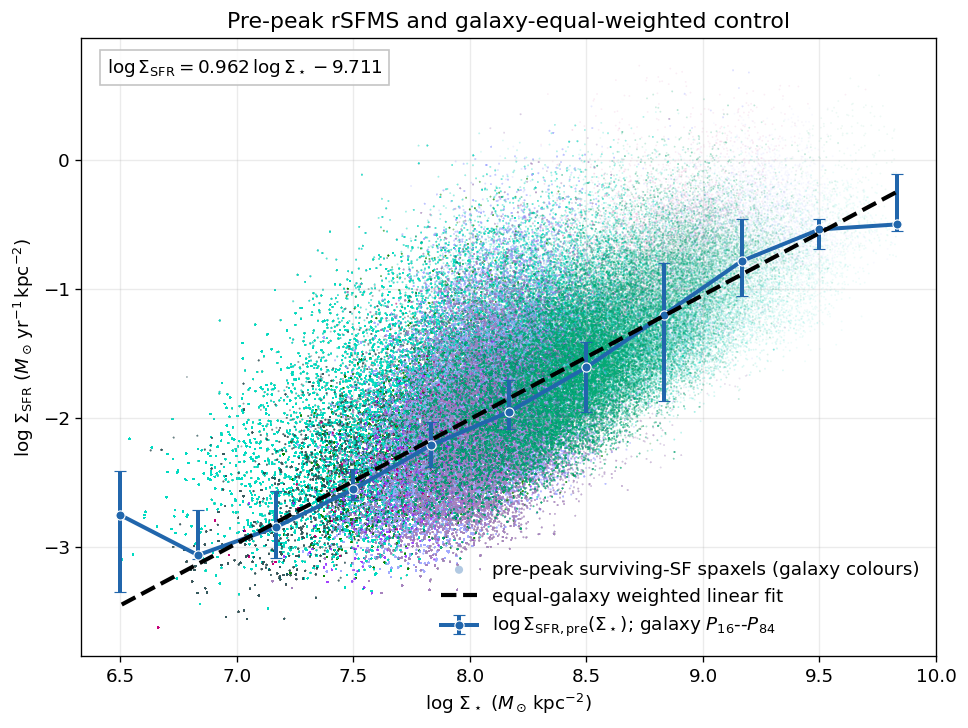

Pre-peak equal-galaxy WLS: slope=0.9625, intercept=-9.7107, N_spaxels=1,743,828, N_galaxies=8


In [6]:
prepeak_galaxies = [
    galid for galid, payload in spaxels.items()
    if payload["stage"] == "pre-peak"
]
galaxy_colors = load_galaxy_colors(GALAXY_COLOR_PATH)

fit_x_parts, fit_y_parts, fit_weight_parts = [], [], []
for galid in prepeak_galaxies:
    payload = spaxels[galid]
    use = np.isfinite(payload["x"]) & np.isfinite(payload["y"]) & np.isfinite(payload["reference"])
    n_use = int(use.sum())
    if n_use:
        fit_x_parts.append(payload["x"][use])
        fit_y_parts.append(payload["y"][use])
        fit_weight_parts.append(np.full(n_use, 1.0 / n_use))

fit_x = np.concatenate(fit_x_parts)
fit_y = np.concatenate(fit_y_parts)
fit_weights = np.concatenate(fit_weight_parts)
fit_design = np.column_stack((fit_x, np.ones_like(fit_x)))
sqrt_weights = np.sqrt(fit_weights)
prepeak_fit_slope, prepeak_fit_intercept = np.linalg.lstsq(
    fit_design * sqrt_weights[:, None], fit_y * sqrt_weights, rcond=None
)[0]

supported_reference = prepeak_reference.loc[
    prepeak_reference.supported
    & prepeak_reference.reference.notna()
    & prepeak_reference.galaxy_p16.notna()
    & prepeak_reference.galaxy_p84.notna()
].copy()
fit_grid = np.linspace(fit_x.min(), fit_x.max(), 200)
supported_bin_lo = int(supported_reference.sigma_bin.min())
supported_bin_hi = int(supported_reference.sigma_bin.max()) + 1

fig, ax = plt.subplots(figsize=(8.2, 6.2))
for index, galid in enumerate(prepeak_galaxies):
    payload = spaxels[galid]
    use = np.isfinite(payload["reference"])
    ax.scatter(
        payload["x"][use], payload["y"][use],
        s=1.2, alpha=0.07, color=galaxy_colors.get(galid, "0.45"),
        edgecolors="none", rasterized=True,
    )

ax.scatter(
    [], [], s=24, alpha=0.35, color=STAGE_COLORS["pre-peak"], edgecolors="none",
    label="pre-peak surviving-SF spaxels (galaxy colours)",
)

control_yerr = np.vstack((
    supported_reference.reference - supported_reference.galaxy_p16,
    supported_reference.galaxy_p84 - supported_reference.reference,
))
ax.errorbar(
    supported_reference.sigma_center, supported_reference.reference,
    yerr=control_yerr, fmt="o-", ms=5.5, lw=2.4, capsize=3.5,
    color=STAGE_COLORS["pre-peak"], markeredgecolor="white", markeredgewidth=0.7,
    label=r"$\log\Sigma_{\rm SFR,pre}(\Sigma_\star)$; galaxy $P_{16}$--$P_{84}$",
    zorder=10,
)
ax.plot(
    fit_grid, prepeak_fit_slope * fit_grid + prepeak_fit_intercept,
    color="black", ls="--", lw=2.5,
    label="equal-galaxy weighted linear fit", zorder=11,
)
ax.text(
    0.03, 0.97,
    rf"$\log\Sigma_{{\rm SFR}}={prepeak_fit_slope:.3f}\,\log\Sigma_\star{prepeak_fit_intercept:+.3f}$",
    transform=ax.transAxes, va="top", ha="left",
    bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.9},
)
ax.set(
    xlabel=r"$\log\,\Sigma_\star\ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=r"$\log\,\Sigma_{\rm SFR}\ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$",
    xlim=(sigma_edges[supported_bin_lo], sigma_edges[supported_bin_hi]),
    title="Pre-peak rSFMS and galaxy-equal-weighted control",
)
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
save_figure(fig, "Fig_Q3_0_prepeak_rSFMS_control", diagnostic=True)
display(fig)
plt.close(fig)

print(
    "Pre-peak equal-galaxy WLS: "
    f"slope={prepeak_fit_slope:.4f}, intercept={prepeak_fit_intercept:.4f}, "
    f"N_spaxels={fit_x.size:,}, N_galaxies={len(fit_x_parts)}"
)

### Control construction checks

Only the supported $\Sigma_\star$ interval is analysed; unsupported edge bins are not extrapolated into Q3. The reference is a median of galaxy medians, while $\sigma_{\rm pre}$ uses equal total weight per contributing pre-peak galaxy. This prevents a spatially large galaxy from defining either the baseline or its width. Because the same pre-peak set defines and is compared with the control, pre-peak residuals are a baseline rather than an external validation sample.

## 6. Figures Q3.1 and Q3.2: equal-galaxy-weighted full residual distributions

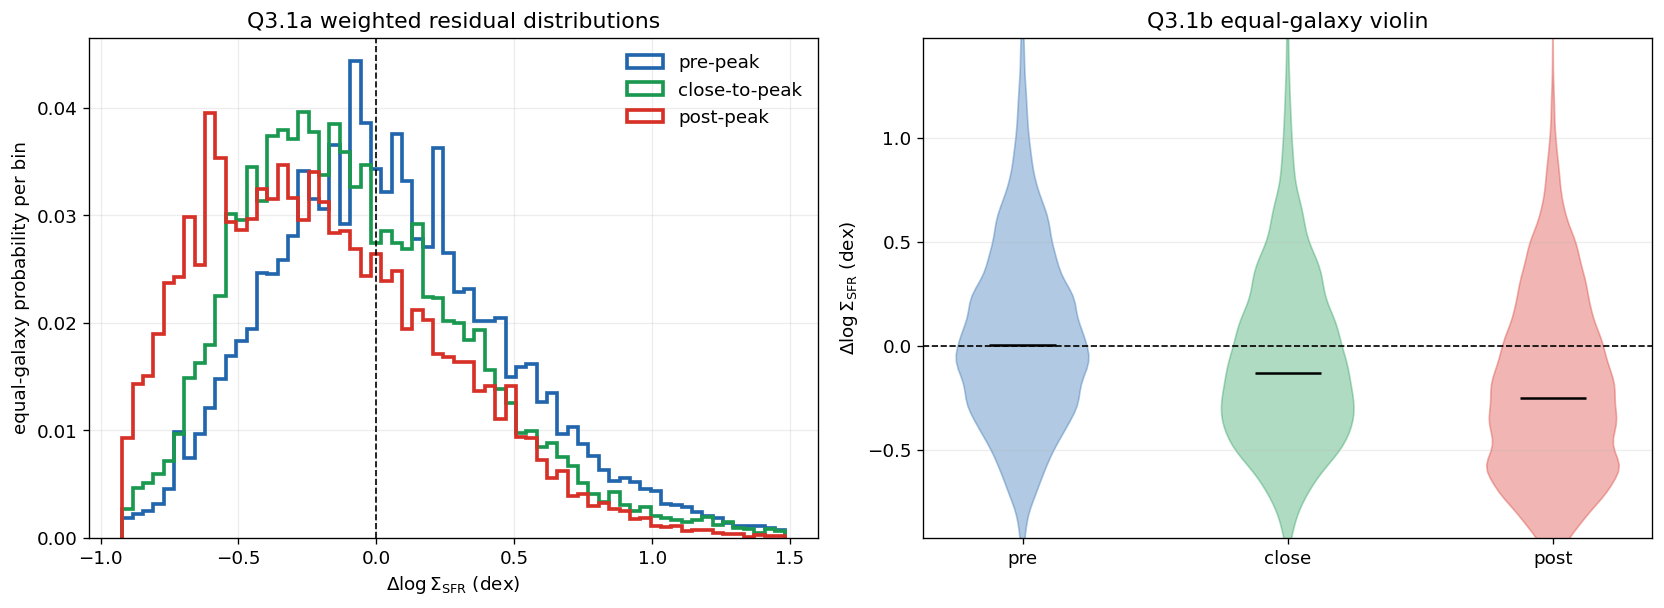

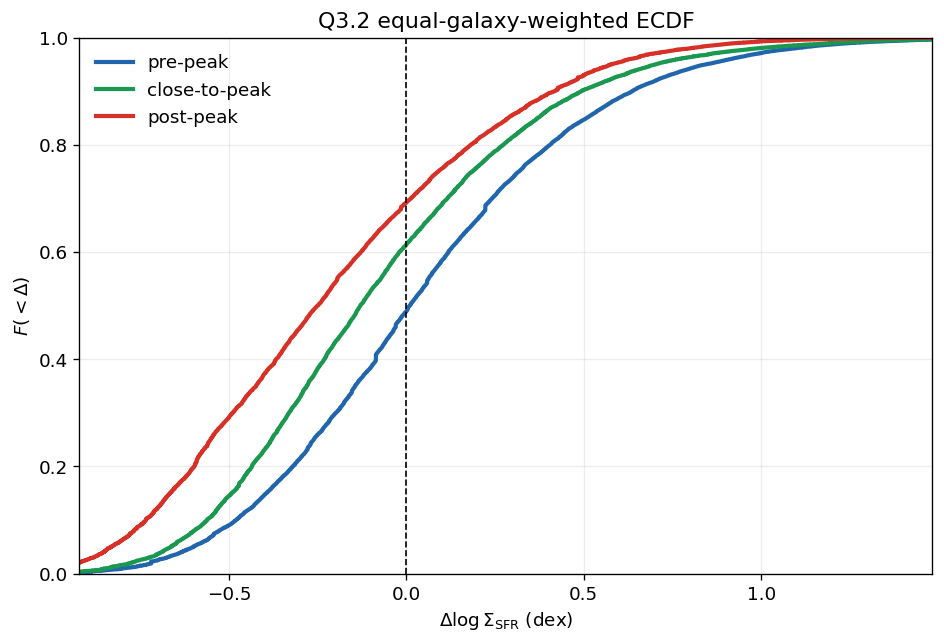

In [7]:
stage_payloads = {stage: equal_galaxy_stage_payload(spaxels, galaxy_metrics, stage) for stage in STAGE_ORDER}
all_values = np.concatenate([stage_payloads[s][0] for s in STAGE_ORDER if stage_payloads[s][0].size])
plot_lo, plot_hi = np.nanpercentile(all_values, [0.5, 99.5])
plot_lo, plot_hi = max(-3.0, plot_lo), min(3.0, plot_hi)
hist_edges = np.linspace(plot_lo, plot_hi, 65)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for stage in STAGE_ORDER:
    values, weights = stage_payloads[stage]
    axes[0].hist(values, bins=hist_edges, weights=weights, histtype="step", lw=2.2,
                 color=STAGE_COLORS[stage], label=stage)
axes[0].axvline(0, color="black", ls="--", lw=1)
axes[0].set(xlabel=r"$\Delta\log\Sigma_{\rm SFR}$ (dex)", ylabel="equal-galaxy probability per bin",
            title="Q3.1a weighted residual distributions")
axes[0].legend(frameon=False); axes[0].grid(alpha=0.22)

rng = np.random.default_rng(RANDOM_SEED)
violin_samples = []
for stage in STAGE_ORDER:
    eligible = galaxy_metrics.loc[galaxy_metrics.stage.eq(stage) & galaxy_metrics.eligible_primary, "GALID"]
    stage_parts = []
    for galid in eligible:
        arr = spaxels[galid]["delta"]
        arr = arr[np.isfinite(arr)]
        stage_parts.append(rng.choice(arr, size=EQUAL_GALAXY_VIOLIN_DRAWS, replace=arr.size < EQUAL_GALAXY_VIOLIN_DRAWS))
    violin_samples.append(np.concatenate(stage_parts))
parts = axes[1].violinplot(violin_samples, positions=np.arange(3), showmedians=True, showextrema=False)
for body, stage in zip(parts["bodies"], STAGE_ORDER):
    body.set_facecolor(STAGE_COLORS[stage]); body.set_edgecolor(STAGE_COLORS[stage]); body.set_alpha(0.35)
parts["cmedians"].set_color("black")
axes[1].axhline(0, color="black", ls="--", lw=1)
axes[1].set_xticks(range(3), ["pre", "close", "post"])
axes[1].set(ylabel=r"$\Delta\log\Sigma_{\rm SFR}$ (dex)", title="Q3.1b equal-galaxy violin")
axes[1].set_ylim(plot_lo, plot_hi); axes[1].grid(axis="y", alpha=0.22)
fig.tight_layout(); save_figure(fig, "Fig_Q3_1_weighted_distribution_and_violin"); plt.show()

fig, ax = plt.subplots(figsize=(8, 5.5))
for stage in STAGE_ORDER:
    values, weights = stage_payloads[stage]
    x_ecdf, y_ecdf = weighted_ecdf(values, weights)
    ax.plot(x_ecdf, y_ecdf, lw=2.5, color=STAGE_COLORS[stage], label=stage)
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_xlim(plot_lo, plot_hi); ax.set_ylim(0, 1)
ax.set(xlabel=r"$\Delta\log\Sigma_{\rm SFR}$ (dex)", ylabel=r"$F(<\Delta)$",
       title="Q3.2 equal-galaxy-weighted ECDF")
ax.legend(frameon=False); ax.grid(alpha=0.22)
fig.tight_layout(); save_figure(fig, "Fig_Q3_2_weighted_ECDF"); plt.show()

### Interpretation of Q3.1--Q3.2

With equal total weight per galaxy, the three distributions are ordered mainly as a **location sequence**, not a close-to-peak broadening sequence. The pre-peak distribution is centred essentially at zero, close-to-peak shifts negative, and post-peak shifts farther negative. The close-to-peak violin does not visibly acquire the hypothesised simultaneous positive and negative excess. The ECDF provides the clearest bin-independent view: close-to-peak lies between pre- and post-peak over most of the displayed residual range. The displayed $0.5$--$99.5$ percentile range is only for legibility; all finite supported residuals enter the galaxy metrics.

## 7. Galaxy-level statistics, bootstrap confidence intervals, and permutation tests

In [8]:
PRIMARY_METRICS = ["M", "W", "f_enh", "f_sup", "F_tail", "A_tail", "S_asym"]
stage_metric_summary = bootstrap_stage_metrics(galaxy_metrics, PRIMARY_METRICS)
permutation_results = permutation_stage_differences(galaxy_metrics, ["M", "W", "f_enh", "f_sup", "F_tail", "A_tail"])

sensitivity_rows = []
for n_min in NMIN_SENSITIVITY:
    for stage in STAGE_ORDER:
        subset = galaxy_metrics.loc[galaxy_metrics.stage.eq(stage) & galaxy_metrics.N_z.ge(n_min)]
        for metric in ("M", "W", "f_enh", "f_sup"):
            sensitivity_rows.append({
                "N_min": n_min, "stage": stage, "metric": metric, "Ngal": len(subset),
                "median": subset[metric].median(),
            })
sensitivity = pd.DataFrame(sensitivity_rows)

display(stage_metric_summary)
display(permutation_results)
display(sensitivity.pivot_table(index=["N_min", "stage", "Ngal"], columns="metric", values="median"))

,metric,stage,Ngal,median,galaxy_p16,galaxy_p84,boot_p2p5,boot_p16,boot_p84,boot_p97p5
0,M,pre-peak,8,-0.001383,-0.161649,0.095608,-0.181612,-0.015256,0.050952,0.099507
1,M,close-to-peak,5,-0.138488,-0.191043,-0.037809,-0.242075,-0.162338,-0.039562,-0.034693
2,M,post-peak,13,-0.242643,-0.507214,-0.017629,-0.447437,-0.373043,-0.078310,-0.057326
3,W,pre-peak,8,0.394516,0.353283,0.472787,0.348991,0.384763,0.437667,0.477235
4,W,close-to-peak,5,0.383635,0.370887,0.453415,0.368756,0.372086,0.432198,0.491134
5,W,post-peak,13,0.375231,0.307435,0.462383,0.327356,0.353222,0.399598,0.455815
6,f_enh,pre-peak,8,0.174631,0.128995,0.229283,0.128090,0.147501,0.182542,0.235657
7,f_enh,close-to-peak,5,0.102361,0.049256,0.184187,0.041588,0.053569,0.183678,0.185091
8,f_enh,post-peak,13,0.054616,0.016812,0.140019,0.030955,0.031754,0.113199,0.117580
9,f_sup,pre-peak,8,0.097205,0.046132,0.214584,0.056384,0.072812,0.122673,0.227117


,metric,comparison,Ngal_a,Ngal_b,observed_difference,p_permutation_two_sided
0,M,close-to-peak_minus_pre-peak,5,8,-0.137104,0.185781
1,M,post-peak_minus_pre-peak,13,8,-0.241260,0.037196
2,W,close-to-peak_minus_pre-peak,5,8,-0.010881,0.694731
3,W,post-peak_minus_pre-peak,13,8,-0.019285,0.559344
4,f_enh,close-to-peak_minus_pre-peak,5,8,-0.072270,0.118988
5,f_enh,post-peak_minus_pre-peak,13,8,-0.120015,0.002000
6,f_sup,close-to-peak_minus_pre-peak,5,8,0.051783,0.255474
7,f_sup,post-peak_minus_pre-peak,13,8,0.140918,0.134687
8,F_tail,close-to-peak_minus_pre-peak,5,8,-0.004654,0.852315
9,F_tail,post-peak_minus_pre-peak,13,8,0.017448,0.545945


metric                           M         W     f_enh     f_sup
N_min stage         Ngal                                        
20    close-to-peak 5    -0.138488  0.383635  0.102361  0.148988
      post-peak     13   -0.242643  0.375231  0.054616  0.238123
      pre-peak      8    -0.001383  0.394516  0.174631  0.097205
50    close-to-peak 5    -0.138488  0.383635  0.102361  0.148988
      post-peak     13   -0.242643  0.375231  0.054616  0.238123
      pre-peak      8    -0.001383  0.394516  0.174631  0.097205
100   close-to-peak 5    -0.138488  0.383635  0.102361  0.148988
      post-peak     13   -0.242643  0.375231  0.054616  0.238123
      pre-peak      8    -0.001383  0.394516  0.174631  0.097205

### Statistical interpretation

All 26 primary products remain eligible at each tested threshold (20, 50, and 100 supported SF spaxels), so the reported stage medians are unchanged across that sensitivity check. The individual galaxy values provide stage scatter; the bootstrap intervals quantify uncertainty on the **stage median** after resampling whole galaxies. Two-sided permutation tests shuffle galaxy labels.

The close-to-pre differences are not permutation-secure for any primary metric: $M=-0.137$ dex ($p_{\rm perm}=0.186$), $W=-0.011$ dex ($p=0.695$), $f_{\rm enh}=-0.072$ ($p=0.119$), and $f_{\rm sup}=+0.052$ ($p=0.255$). Post-to-pre has a clearer survivor shift: $M=-0.241$ dex ($p=0.037$), $f_{\rm enh}=-0.120$ ($p=0.002$), and $A_{\rm tail}=-0.276$ ($p=0.039$). The increase in post-peak $f_{\rm sup}$ is large in median but heterogeneous and not permutation-secure ($p=0.135$).

## 8. Figure Q3.3: individual-galaxy location and width

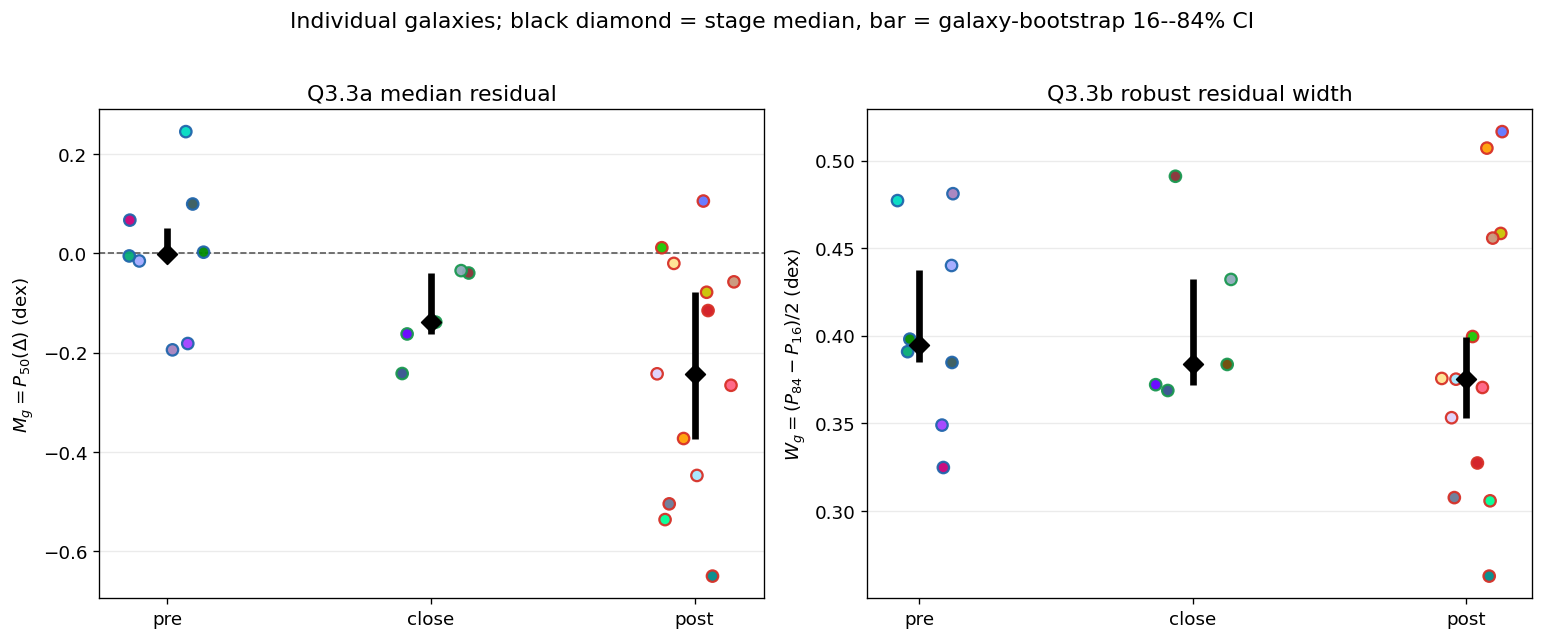

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
draw_stage_points_and_summary(axes[0], galaxy_metrics, stage_metric_summary, "M", r"$M_g=P_{50}(\Delta)$ (dex)", zero=True)
draw_stage_points_and_summary(axes[1], galaxy_metrics, stage_metric_summary, "W", r"$W_g=(P_{84}-P_{16})/2$ (dex)")
axes[0].set_title("Q3.3a median residual")
axes[1].set_title("Q3.3b robust residual width")
fig.suptitle("Individual galaxies; black diamond = stage median, bar = galaxy-bootstrap 16--84% CI", y=1.02)
fig.tight_layout(); save_figure(fig, "Fig_Q3_3_galaxy_median_width"); plt.show()

### Interpretation of Q3.3

The stage medians are $M_g=-0.001$, $-0.138$, and $-0.243$ dex for pre-, close-, and post-peak, respectively. Thus the surviving population trends downward through the adopted stage sequence; only the post-to-pre median difference is supported by the current galaxy-label permutation test ($p=0.037$). The robust widths are $W_g=0.395$, $0.384$, and $0.375$ dex. Close-to-peak is therefore **not broader** than pre-peak in this analysis ($\Delta W=-0.011$ dex, $p=0.695$), contrary to the main heterogeneous-redistribution hypothesis. Point colours follow the fixed MAUVE palette and stage inference is based on galaxies, not spaxel counts.

## 9. Figure Q3.4: enhanced and suppressed fractions

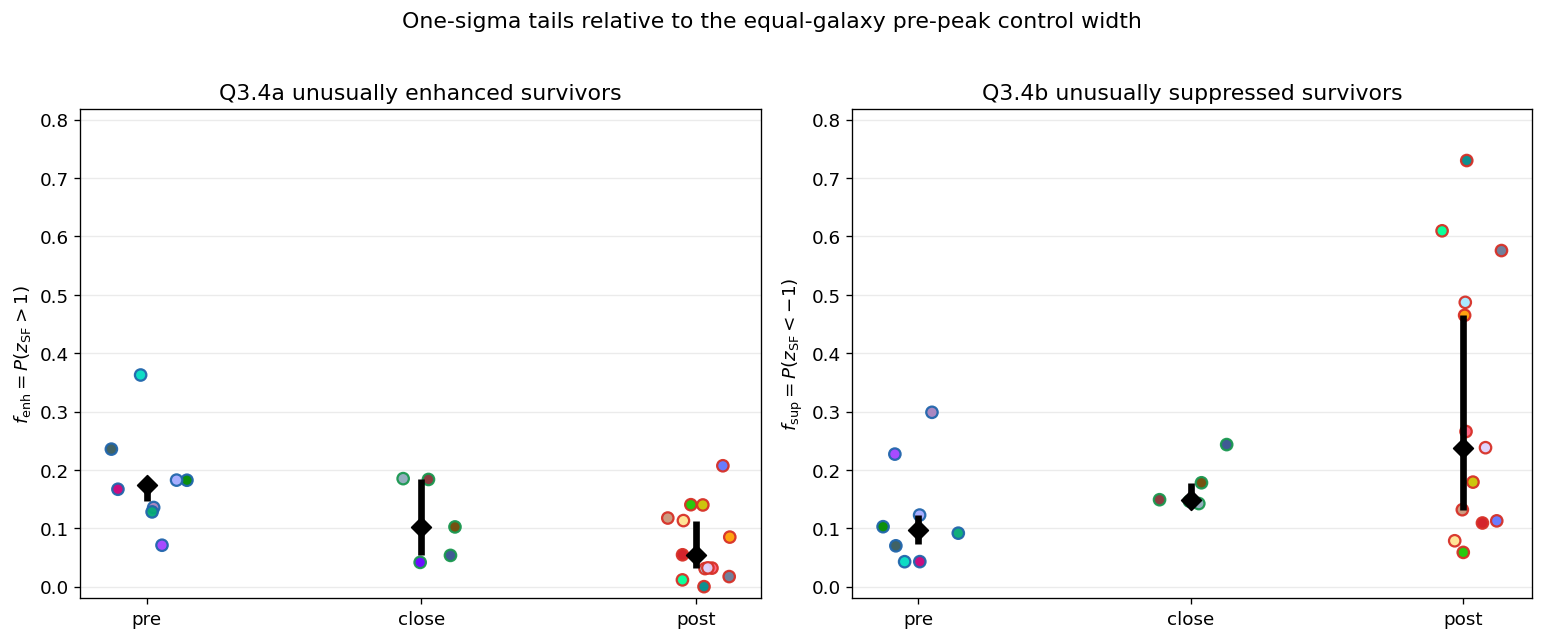

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
draw_stage_points_and_summary(axes[0], galaxy_metrics, stage_metric_summary, "f_enh", r"$f_{\rm enh}=P(z_{\rm SF}>1)$")
draw_stage_points_and_summary(axes[1], galaxy_metrics, stage_metric_summary, "f_sup", r"$f_{\rm sup}=P(z_{\rm SF}<-1)$")
for ax in axes: ax.set_ylim(-0.02, min(1.0, max(0.5, galaxy_metrics[["f_enh", "f_sup"]].max().max() * 1.12)))
axes[0].set_title("Q3.4a unusually enhanced survivors")
axes[1].set_title("Q3.4b unusually suppressed survivors")
fig.suptitle("One-sigma tails relative to the equal-galaxy pre-peak control width", y=1.02)
fig.tight_layout(); save_figure(fig, "Fig_Q3_4_enhanced_suppressed_fractions"); plt.show()

### Interpretation of Q3.4

The enhanced fraction decreases from 0.175 (pre) to 0.102 (close) and 0.055 (post). The post-to-pre reduction is the strongest tail result ($p_{\rm perm}=0.002$); the close-to-pre reduction remains suggestive only ($p=0.119$). The suppressed fraction rises from 0.097 to 0.149 to 0.238, but large post-peak galaxy-to-galaxy scatter weakens the permutation evidence ($p=0.135$ for post-to-pre). Hence the secure post-peak signal is not simply “more extreme suppressed spaxels”; it is a combination of a negative survivor median, loss of the enhanced tail, and a more suppression-dominated tail balance.

## 10. Figure Q3.5: tail phase space

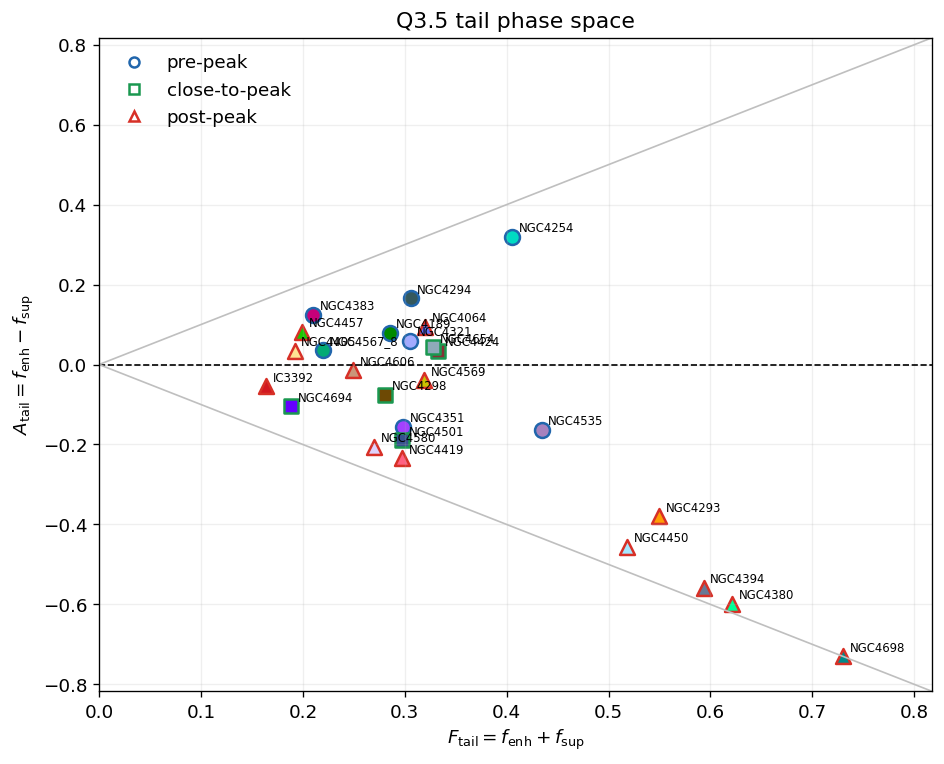

In [11]:
galaxy_colors = load_galaxy_colors(GALAXY_COLOR_PATH)
stage_markers = {"pre-peak": "o", "close-to-peak": "s", "post-peak": "^"}
fig, ax = plt.subplots(figsize=(8, 6.5))
for row in galaxy_metrics.loc[galaxy_metrics.eligible_primary].itertuples(index=False):
    ax.scatter(row.F_tail, row.A_tail, s=80, marker=stage_markers[row.stage],
               color=galaxy_colors.get(row.GALID, "0.45"), edgecolor=STAGE_COLORS[row.stage], linewidth=1.5)
    ax.annotate(row.GALID, (row.F_tail, row.A_tail), xytext=(4, 3), textcoords="offset points", fontsize=7)
xmax = min(1.0, galaxy_metrics.loc[galaxy_metrics.eligible_primary, "F_tail"].max() * 1.12)
ax.axhline(0, color="black", ls="--", lw=1)
ax.plot([0, xmax], [0, xmax], color="0.75", lw=1)
ax.plot([0, xmax], [0, -xmax], color="0.75", lw=1)
ax.set(xlim=(0, xmax), ylim=(-xmax, xmax), xlabel=r"$F_{\rm tail}=f_{\rm enh}+f_{\rm sup}$",
       ylabel=r"$A_{\rm tail}=f_{\rm enh}-f_{\rm sup}$", title="Q3.5 tail phase space")
handles = [plt.Line2D([], [], marker=stage_markers[s], ls="", markerfacecolor="white",
                      markeredgecolor=STAGE_COLORS[s], markeredgewidth=1.5, label=s) for s in STAGE_ORDER]
ax.legend(handles=handles, frameon=False, loc="best"); ax.grid(alpha=0.2)
fig.tight_layout(); save_figure(fig, "Fig_Q3_5_tail_phase_space"); plt.show()

### Interpretation of Q3.5

The total unusual fraction $F_{\rm tail}$ is nearly unchanged in the stage medians (0.302, 0.297, 0.319), and neither stage differs securely from pre-peak. What changes is the balance: $A_{\rm tail}$ moves from $+0.070$ (pre) to $-0.076$ (close) and $-0.206$ (post). The close-to-pre change is not secure ($p=0.148$), while post-to-pre is ($p=0.039$). Several post-peak galaxies occupy the high-$F_{\rm tail}$, strongly negative-$A_{\rm tail}$ region, but others overlap the control; the stage result is therefore suppression-dominated with substantial galaxy diversity, not a universal trajectory.

## 11. Figure Q3.6: retain $\Sigma_\star$ information

The residual removes the first-order pre-peak relation, but its upper and lower widths may still vary with $\Sigma_\star$. We therefore compute each galaxy's $P_{16}$, $P_{50}$, and $P_{84}$ residual in every common stellar-density bin, then take stage medians across galaxies.

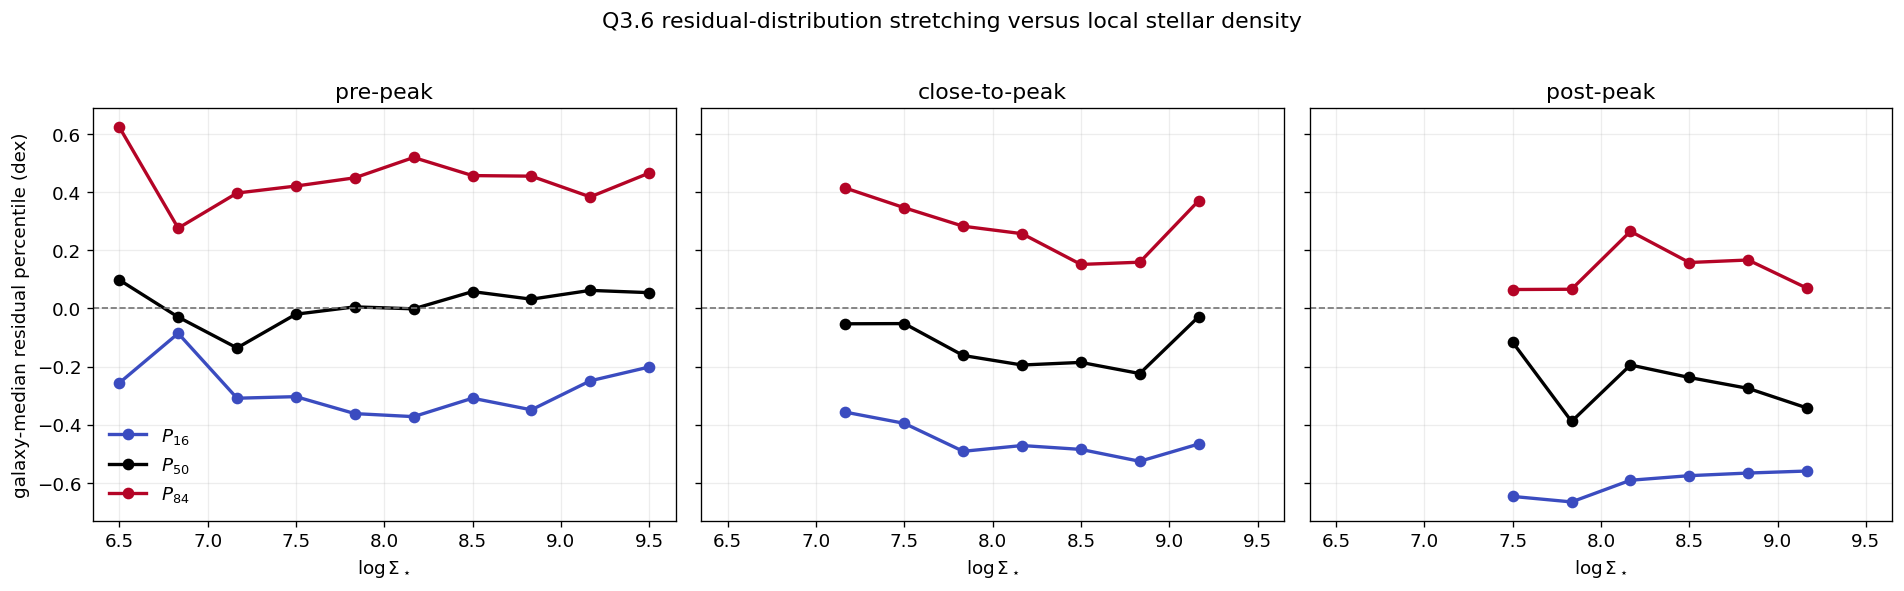

In [12]:
quantile_rows = []
for galid, payload in spaxels.items():
    for j in range(N_SIGMA_BINS):
        use = (payload["bin_index"] == j) & np.isfinite(payload["delta"])
        values = payload["delta"][use]
        if values.size >= MIN_SF_PIXELS_PER_BIN:
            p16, p50, p84 = np.percentile(values, [16, 50, 84])
        else:
            p16 = p50 = p84 = np.nan
        quantile_rows.append({"GALID": galid, "stage": payload["stage"], "sigma_bin": j,
                              "sigma_center": sigma_centres[j], "N_SF": values.size,
                              "P16": p16, "P50": p50, "P84": p84})
quantiles_by_galaxy = pd.DataFrame(quantile_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
for ax, stage in zip(axes, STAGE_ORDER):
    stage_frame = quantiles_by_galaxy.loc[quantiles_by_galaxy.stage.eq(stage)]
    for column, color, label in (("P16", "#3b4cc0", r"$P_{16}$"),
                                  ("P50", "black", r"$P_{50}$"),
                                  ("P84", "#b40426", r"$P_{84}$")):
        curve = stage_frame.groupby("sigma_center")[column].agg(["median", "count"]).reset_index()
        curve = curve.loc[curve["count"].ge(MIN_GALAXIES_PER_STAGE_BIN)]
        ax.plot(curve.sigma_center, curve["median"], marker="o", lw=2, color=color, label=label)
    ax.axhline(0, color="0.45", ls="--", lw=1)
    ax.set_title(stage); ax.grid(alpha=0.22); ax.set_xlabel(r"$\log\Sigma_\star$")
axes[0].set_ylabel(r"galaxy-median residual percentile (dex)")
axes[0].legend(frameon=False)
fig.suptitle("Q3.6 residual-distribution stretching versus local stellar density", y=1.02)
fig.tight_layout(); save_figure(fig, "Fig_Q3_6_residual_quantiles_vs_SigmaStar"); plt.show()

### Interpretation of Q3.6

Across the supported $\Sigma_\star$ range, the close-to-peak percentile curves are primarily displaced downward rather than showing the hypothesised $P_{84}$ rise together with a $P_{16}$ fall. The post-peak lower and median percentiles are more negative, consistent with the galaxy-level suppression result. The exact separation is stellar-density dependent and the edge bins have only the minimum number of contributing galaxies, so this figure should be used to locate the trend—not to replace the galaxy-level permutation tests.

## 12. End-of-notebook numerical diagnostic

In [13]:
core = stage_metric_summary.loc[stage_metric_summary.metric.isin(["M", "W", "f_enh", "f_sup"]),
                                ["metric", "stage", "Ngal", "median", "boot_p16", "boot_p84", "boot_p2p5", "boot_p97p5"]]
close_pre = permutation_results.loc[permutation_results.comparison.eq("close-to-peak_minus_pre-peak")].set_index("metric")
post_pre = permutation_results.loc[permutation_results.comparison.eq("post-peak_minus_pre-peak")].set_index("metric")
display(core)
print("Close - pre effect sizes and two-sided galaxy-label permutation p-values:")
for metric in ["M", "W", "f_enh", "f_sup", "F_tail", "A_tail"]:
    row = close_pre.loc[metric]
    print(f"  {metric:7s}: difference={row.observed_difference:+.4f}, p_perm={row.p_permutation_two_sided:.4f}")
print("Post - pre effect sizes and two-sided galaxy-label permutation p-values:")
for metric in ["M", "W", "f_enh", "f_sup", "F_tail", "A_tail"]:
    row = post_pre.loc[metric]
    print(f"  {metric:7s}: difference={row.observed_difference:+.4f}, p_perm={row.p_permutation_two_sided:.4f}")
print("\nDecision framework:")
print("- Broader close-to-peak W with both tails elevated: heterogeneous redistribution (Case A).")
print("- Negative close-to-peak M with only f_sup elevated: predominant suppression (Case B).")
print("- Positive M with f_enh >> f_sup: widespread enhancement (Case C).")
print("- No supported changes: environment mainly removes regions from the SF population (Case D).")
print("Q4 spatial localisation remains deferred until these Q3 results are interpreted.")

,metric,stage,Ngal,median,boot_p16,boot_p84,boot_p2p5,boot_p97p5
0,M,pre-peak,8,-0.001383,-0.015256,0.050952,-0.181612,0.099507
1,M,close-to-peak,5,-0.138488,-0.162338,-0.039562,-0.242075,-0.034693
2,M,post-peak,13,-0.242643,-0.373043,-0.078310,-0.447437,-0.057326
3,W,pre-peak,8,0.394516,0.384763,0.437667,0.348991,0.477235
4,W,close-to-peak,5,0.383635,0.372086,0.432198,0.368756,0.491134
5,W,post-peak,13,0.375231,0.353222,0.399598,0.327356,0.455815
6,f_enh,pre-peak,8,0.174631,0.147501,0.182542,0.128090,0.235657
7,f_enh,close-to-peak,5,0.102361,0.053569,0.183678,0.041588,0.185091
8,f_enh,post-peak,13,0.054616,0.031754,0.113199,0.030955,0.117580
9,f_sup,pre-peak,8,0.097205,0.072812,0.122673,0.056384,0.227117


Close - pre effect sizes and two-sided galaxy-label permutation p-values:
  M      : difference=-0.1371, p_perm=0.1858
  W      : difference=-0.0109, p_perm=0.6947
  f_enh  : difference=-0.0723, p_perm=0.1190
  f_sup  : difference=+0.0518, p_perm=0.2555
  F_tail : difference=-0.0047, p_perm=0.8523
  A_tail : difference=-0.1454, p_perm=0.1483
Post - pre effect sizes and two-sided galaxy-label permutation p-values:
  M      : difference=-0.2413, p_perm=0.0372
  W      : difference=-0.0193, p_perm=0.5593
  f_enh  : difference=-0.1200, p_perm=0.0020
  f_sup  : difference=+0.1409, p_perm=0.1347
  F_tail : difference=+0.0174, p_perm=0.5459
  A_tail : difference=-0.2757, p_perm=0.0389

Decision framework:
- Broader close-to-peak W with both tails elevated: heterogeneous redistribution (Case A).
- Negative close-to-peak M with only f_sup elevated: predominant suppression (Case B).
- Positive M with f_enh >> f_sup: widespread enhancement (Case C).
- No supported changes: environment mainly remo

## Final scientific synthesis

The current Q3 result does **not** support the proposed close-to-peak broadening/redistribution signature. Close-to-peak galaxies have a more negative median survivor residual, fewer enhanced regions, and more suppressed regions than the pre-peak control, but none of those five-galaxy differences is permutation-secure; $W_g$ is essentially unchanged. This is closer to the suppression-oriented Case B than Case A, but should be described as a trend rather than a detection.

Post-peak galaxies show the clearer transformation among survivors: the median is lower by 0.241 dex, the enhanced fraction is lower, and the tail balance is significantly more suppression dominated. The total tail fraction and robust width do not increase. Combined with the earlier Q1 result that post-peak evolution is dominated by disappearance of SF regions, the paper-shaped interpretation is: **RPS mainly removes regions from the SF population, and the post-peak regions that survive are shifted toward weaker, suppression-dominated star formation rather than a broadened or enhancement-rich state.**

If Q4 is pursued, these Q3 results favour asking where the suppressed surviving regions lie; maps of enhanced regions should be retained as a secondary check rather than assumed to be the main signal. Important caveats are the internally defined pre-peak baseline, only five close-to-peak galaxies, sparse support at the stellar-density edges, and substantial post-peak galaxy diversity. No external figures or tables were written; the results and figures are embedded here.